In [1]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math
import pickle
import os

In [2]:
# ====================================
# Physical & Simulation Parameters
# ====================================
# Theta angle in degrees, H_Coll Direction
theta_target_deg = 0.0  # change angle here
theta_rad = np.radians(theta_target_deg)

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time step
dt = 0.01

# Number of trajectories to analyze
N_traj = 10000          

In [3]:
# ===========================
# General Setup for Plotting
# ===========================
# --- 1. Output Directory---

if theta_target_deg.is_integer():
    angle_folder = str(int(theta_target_deg))
else:
    angle_folder = str(theta_target_deg)

Output_dir = os.path.join("../../Results/Plot/Populations", angle_folder)
os.makedirs(Output_dir, exist_ok=True)

# --- 2. Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- 3. Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

In [4]:
# =================
# Input Data Setup
# =================
Input_dir = "../../Results/Data/Complete_rho"

# Format theta and dt for filename 
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# File name
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
#filename = "result_theta0p000000_dt0p010000_Ntraj20000.npz"  # only for 0.0 deg
filepath = os.path.join(Input_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

Analisi impostata per theta = 0.0°
File target: result_theta0p000000_dt0p010000_Ntraj20000.npz


In [5]:
if not os.path.exists(filepath):
    print(f"ERRORE: Il file {filepath} non esiste. Controlla di aver completato la simulazione per questo angolo.")
else:
    print("Estrazione Dati")
    # Caricamento del dizionario compresso
    data = np.load(filepath)
    
    times = data['times']
    
    # 1. Curve Analitiche (Baseline)
    pop_iso = data['pop_traj_isolated']
    pops_trace = data['pops_trace']
    
    # Per Lindblad, estraiamo gli elementi diagonali rilevanti dalla matrice 4x4
    # P_10 corrisponde all'indice (2,2) e P_01 all'indice (1,1)
    rho_lindblad = data['rho_list_lindblad']
    pop_lindblad_10 = np.real(rho_lindblad[:, 2, 2])
    pop_lindblad_01 = np.real(rho_lindblad[:, 1, 1])
    cohe_lindblad_10_01 = rho_lindblad[:, 2, 1]
    cohe_lindblad_01_10 = rho_lindblad[:, 1, 2]
    
    # 2. Matrici Raw delle Distribuzioni
    # pop_00 nel codice salvava il sito 1 (|10>), pop_11 salvava il sito 2 (|01>)
    raw_pop_10 = data['pop_00'] 
    raw_pop_01 = data['pop_11']
    raw_cohe_10_01 = data['coh_10_01']
    raw_cohe_01_10 = data['coh_01_10']
    
    # 3. Slicing Dinamico per le Medie Stocastiche
    # Calcoliamo le medie lungo le colonne (axis=1) prendendo solo i primi N elementi
    # Definisci i numeri di traiettorie su cui vuoi fare le medie
    N_traj_list_plot = [100, 1000, 10000, 20000]
    
    # Inizializza i dizionari
    avg_pop_10 = {}
    avg_pop_01 = {}
    avg_cohe_10_01 = {}
    avg_cohe_01_10 = {}

    # Calcolo dinamico con un ciclo
    for N in N_traj_list_plot:
        # Controlliamo che N non superi il numero di colonne effettivamente salvate
        max_N = min(N, raw_pop_10.shape[1]) 
        
        avg_pop_10[N] = np.mean(raw_pop_10[:, :max_N], axis=1)
        avg_pop_01[N] = np.mean(raw_pop_01[:, :max_N], axis=1)
        
        avg_cohe_10_01[N] = np.mean(raw_cohe_10_01[:, :max_N], axis=1)
        avg_cohe_01_10[N] = np.mean(raw_cohe_01_10[:, :max_N], axis=1)
    
    # Estraiamo le prime 50 traiettorie singole per il background visivo
    single_trajs_10 = raw_pop_10[:, :50]
    single_trajs_01 = raw_pop_01[:, :50]
    
    print("Dati estratti e medie calcolate con successo!")

Estrazione Dati
Dati estratti e medie calcolate con successo!


In [6]:
# ============================
# Site Selection and Labeling
# ============================
if site_index == 0:
    pop_lindblad = pop_lindblad_10
    avg_pop = avg_pop_10[N_traj]
    label_site = r"1 ($|10\rangle$)"
    single_trajs = single_trajs_10
else:
    pop_lindblad = pop_lindblad_01
    avg_pop = avg_pop_01[N_traj]
    label_site = "2 (|01>)"
    single_trajs = single_trajs_01

Figure saved in: ../../Results/Plot/Populations/0/Comparison Lindblad, Trace, Avg Trajectories - dt=0.01 & N_traj=10000


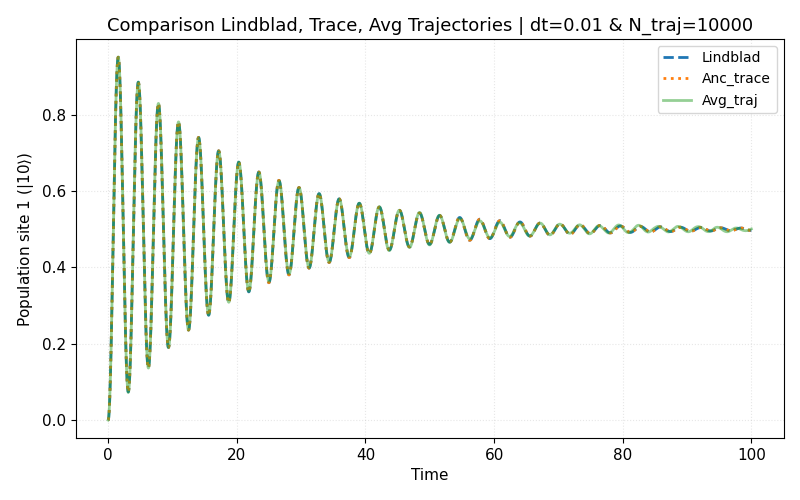

In [7]:
# ====================================
# Convergence Avg vs Trace vs Linblad
# ====================================

plt.close('all')

fig01, ax = plt.subplots()

ax.plot(times, pop_lindblad, label=r'Lindblad', linewidth=2, linestyle='--')
ax.plot(times, pops_trace[site_index, :], label=r'Anc_trace', linewidth=2, linestyle=':')
ax.plot(times, avg_pop, label=r'Avg_traj', linewidth=2, alpha=0.5)

ax.set_title(f'Comparison Lindblad, Trace, Avg Trajectories | dt={dt} & N_traj={N_traj}')
ax.set_xlabel('Time')
ax.set_ylabel(f'Population site {label_site} ') # change site
ax.legend()

# Automatically save the figure (PNG + PDF)
filename_01 = f'Comparison Lindblad, Trace, Avg Trajectories - dt={dt} & N_traj={N_traj}'
save_fig(fig01, filename_01)

plt.show()

Figure saved in: ../../Results/Plot/Populations/0/Comparison Collisional vs Isolated - dt=0.01 & N_traj=10000


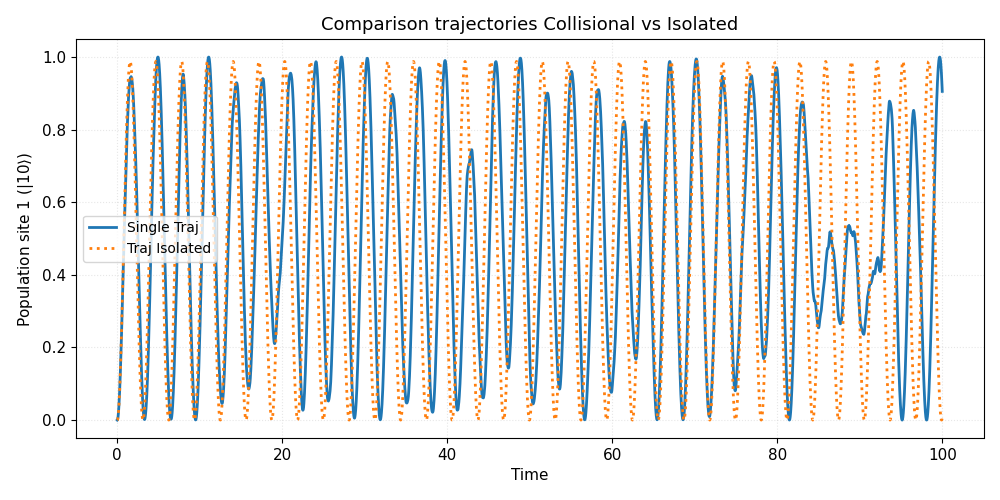

In [8]:
# ================================================
# Comparison trajectories Collisional vs Isolated
# ================================================

plt.close('all')

sample_idx = 0

fig02, ax = plt.subplots(figsize=(10,5))

ax.plot(times, single_trajs[:,sample_idx], label='Single Traj', linewidth=2)
ax.plot(times, pop_iso[site_index,:], label='Traj Isolated', linewidth=2, linestyle=':')

ax.set_title(r'Comparison trajectories Collisional vs Isolated')
ax.set_xlabel('Time')
ax.set_ylabel(f'Population site {label_site} ')
ax.legend()

# Automatically save the figure (PNG + PDF)
filename_02 = f'Comparison Collisional vs Isolated - dt={dt} & N_traj={N_traj}'
save_fig(fig02, filename_02)

plt.show()


Figure saved in: ../../Results/Plot/Populations/0/Comparison Many Trajectories vs Average


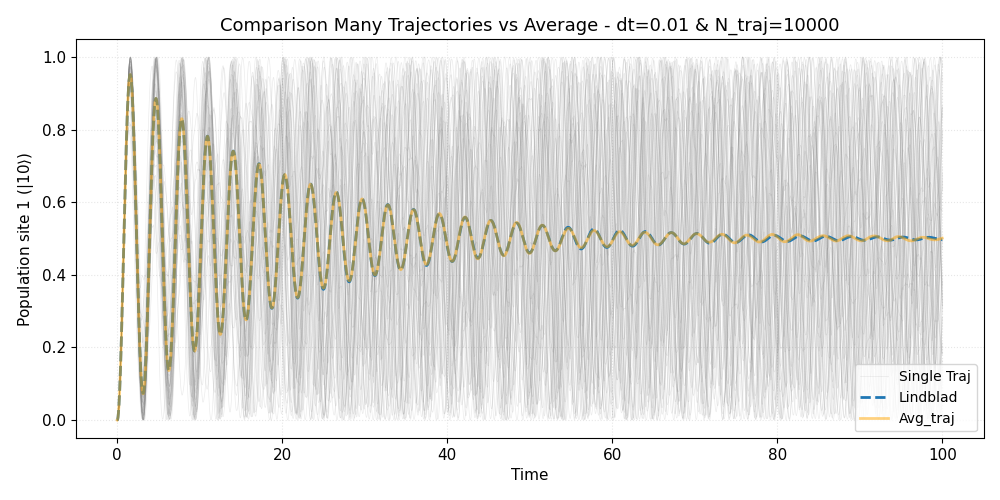

In [9]:
# ===================================================
# Comparison Single Trajectory vs Average vs Lindblad
# ===================================================

plt.close('all')

fig03, ax = plt.subplots(figsize=(10, 5))

for i in range(single_trajs_01.shape[1]):
    ax.plot(times, single_trajs[:, i], color='gray', alpha=0.15, linewidth=0.5, 
             label='Single Traj' if i==0 else "")

ax.plot(times, pop_lindblad, label=r'Lindblad', linewidth=2, linestyle='--')
ax.plot(times, avg_pop, label=r'Avg_traj', linewidth=2, color='orange',  alpha=0.5)

ax.set_title(f'Comparison Many Trajectories vs Average - dt={dt} & N_traj={N_traj}')
ax.set_xlabel('Time')
ax.set_ylabel(f'Population site {label_site} ') # change site
ax.legend()

# Automatically save the figure (PNG + PDF)
filename_03 = 'Comparison Many Trajectories vs Average'
save_fig(fig03, filename_03)
plt.show()

In [10]:
fig04, ax = plt.subplots(figsize=(10, 5))

plt.close('all')

# -----------
# Populations
# -----------
#ax.plot(times, avg_pop_10[N_traj], label=r'pop 1')
#ax.plot(times, avg_pop_01[N_traj], label=r'pop 2') 

#ax.plot(times, pop_lindblad_10, label=r'pop 1 Lindblad', linewidth=2, linestyle='--')
#ax.plot(times, pop_lindblad_01, label=r'pop 2 Lindblad', linewidth=2, linestyle='--')

# ---------------
# Real Coherences
# ---------------
#ax.plot(times, np.real(avg_cohe_10_01[N_traj]), label=r'cohe 1')
#ax.plot(times, np.real(avg_cohe_01_10[N_traj]), label=r'cohe 2')

#ax.plot(times, np.real(cohe_lindblad_01_10), label=r'cohe 1 Lindblad', linewidth=2, linestyle='--')
#ax.plot(times, np.real(cohe_lindblad_10_01), label=r'cohe 2 Lindblad', linewidth=2, linestyle='--')

# --------------------
# Imaginary Coherences
# --------------------
ax.plot(times, np.imag(avg_cohe_10_01[N_traj]), label=r'cohe 1')
#ax.plot(times, np.imag(avg_cohe_01_10[N_traj]), label=r'cohe 2')

ax.plot(times, np.imag(cohe_lindblad_10_01), label=r'cohe 2 Lindblad', linewidth=2, linestyle='--')
#ax.plot(times, np.imag(cohe_lindblad_01_10), label=r'cohe 1 Lindblad', linewidth=2, linestyle='--')

ax.set_title(f'Comparison Lindblad vs Average, Pop, Real and Imag Cohe - dt={dt} & N_traj={N_traj} ')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()

plt.show()